<a href="https://colab.research.google.com/github/areesha-del/google-colab-tasks/blob/main/WEEK_5%2CDAY_(1)_CLASSWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab Task: Abusive Language Detection using NLP**



**INTALL LIABRARIES**

In [ ]:
pip install requests beautifulsoup4 pandas


**DOWNLOAD DATASET USING SCRAPPING**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import random
import time

headers = {
    "User-Agent": "Mozilla/5.0"
}

subreddits = ["politics", "gaming", "news", "technology"]

comments_data = []

abusive_keywords = [
    "idiot", "stupid", "hate", "dumb",
    "loser", "useless", "trash", "fool"
]

for sub in subreddits:

    url = f"https://old.reddit.com/r/{sub}/"
    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")

    posts = soup.find_all("a", class_="comments")

    for post in posts[:10]:   # limit posts

        post_url = post["href"]

        try:
            post_response = requests.get(post_url, headers=headers)
            post_soup = BeautifulSoup(post_response.text, "html.parser")

            comments = post_soup.find_all("div", class_="md")

            for comment in comments:
                text = comment.text.strip()

                if len(text.split()) < 3:
                    continue

                if any(word in text.lower() for word in abusive_keywords):
                    label = 1
                else:
                    label = 0

                comments_data.append([text, label])

                if len(comments_data) >= 400:
                    break

            time.sleep(1)

        except:
            continue

        if len(comments_data) >= 400:
            break

# Convert to DataFrame
df = pd.DataFrame(comments_data, columns=["text", "label"])

# Balance dataset
abusive_df = df[df["label"] == 1].head(100)
non_abusive_df = df[df["label"] == 0].head(100)

final_df = pd.concat([abusive_df, non_abusive_df])
final_df = final_df.sample(frac=1).reset_index(drop=True)

# Save
final_df.to_csv("toxic_scraped_dataset.csv", index=False)

print("Dataset Created Successfully!")
print(final_df["label"].value_counts())

Dataset Created Successfully!
Series([], Name: count, dtype: int64)


**Exercise 1: Data Loading & Inspection**

In [ ]:
import pandas as pd

# 1️⃣ Load the dataset
df = pd.read_csv("/content/toxic_dataset.csv")

print("First 5 Rows:\n")
print(df.head())

# 2️⃣ Display dataset shape
print("\n----------------------------")
print("Dataset Shape:", df.shape)

# 3️⃣ Check for null values
print("\n----------------------------")
print("Null Values:\n")
print(df.isnull().sum())

# If null values exist, remove them
df = df.dropna()

# 4️⃣ Display class distribution
print("\n----------------------------")
print("Class Distribution:\n")
print(df["label"].value_counts())

print("\nClass Percentage:\n")
print(df["label"].value_counts(normalize=True) * 100)

# 5️⃣ Check if dataset is balanced or imbalanced
print("\n----------------------------")
class_counts = df["label"].value_counts()

if len(class_counts) == 2 and abs(class_counts.iloc[0] - class_counts.iloc[1]) < 10:
    print("Dataset is Balanced ✅")
else:
    print("Dataset is Imbalanced ❌")

First 5 Rows:

                                                text  label
0  RT @BootyGangCult: Some of you bitches aren&#8...      1
1  Have a Wonderful DAY!!! Visit https://example....      0
2  Have a Wonderful DAY!!! Visit https://example....      0
3  RT @ImNeverChillin: Any bitch that tell you "I...      1
4  Have a Wonderful DAY!!! Visit https://example....      0

----------------------------
Dataset Shape: (300, 2)

----------------------------
Null Values:

text     0
label    0
dtype: int64

----------------------------
Class Distribution:

label
1    150
0    150
Name: count, dtype: int64

Class Percentage:

label
1    50.0
0    50.0
Name: proportion, dtype: float64

----------------------------
Dataset is Balanced ✅


**CLASS DISTRIBUTION AND PERSONTAGE**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/toxic_dataset.csv")

print("Class Distribution:\n", df['label'].value_counts())
print("\nPercentage:\n", df['label'].value_counts(normalize=True)*100)

Class Distribution:
 label
1    150
0    150
Name: count, dtype: int64

Percentage:
 label
1    50.0
0    50.0
Name: proportion, dtype: float64


**SHOW DATASET**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/toxic_dataset.csv")
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (300, 2)
                                                text  label
0  RT @BootyGangCult: Some of you bitches aren&#8...      1
1  Have a Wonderful DAY!!! Visit https://example....      0
2  Have a Wonderful DAY!!! Visit https://example....      0
3  RT @ImNeverChillin: Any bitch that tell you "I...      1
4  Have a Wonderful DAY!!! Visit https://example....      0


**IMPORT LIABRARIES FOR PREPROCESSING**

In [ ]:
import nltk

# Download the usual punkt
nltk.download('punkt')

# Some environments require punkt_tab explicitly
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

In [ ]:
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r'\w+')

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'(.)\1+', r'\1\1', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    tokens = tokenizer.tokenize(text)  # safer tokenizer
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)



**Exercise 2: Text Preprocessing**

In [ ]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')       # in case some function needs it
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Load dataset
df = pd.read_csv("/content/toxic_dataset.csv")

# Initialize
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r'\w+')  # safe tokenizer

# Preprocessing function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'(.)\1+', r'\1\1', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    tokens = tokenizer.tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

print("Before:", df['text'].iloc[0])
print("After :", df['clean_text'].iloc[0])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Before: RT @BootyGangCult: Some of you bitches aren&#8217;t built to wear certain shit. http://t.co/IjTJvYY2VY
After : rt bootygangcult bitch arent built wear certain shit




**Exercise 3: Feature Engineering using Bag of Words**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
cv = CountVectorizer(max_features=5000)

# Fit and transform
X_bow = cv.fit_transform(df['clean_text'])

# Display document-term matrix shape
print("BoW Matrix Shape:", X_bow.shape)
print("Vocabulary Size:", len(cv.vocabulary_))

# Example: show first 10 words
print("\nFirst 10 words in vocabulary:", list(cv.vocabulary_.keys())[:10])

# Limitation note:
print("\nBoW Limitations:")
print("- Ignores word order")
print("- High dimensionality for large corpus")
print("- All words are equally weighted")

BoW Matrix Shape: (300, 754)
Vocabulary Size: 754

First 10 words in vocabulary: ['rt', 'bootygangcult', 'bitch', 'arent', 'built', 'wear', 'certain', 'shit', 'wonderful', 'day']

BoW Limitations:
- Ignores word order
- High dimensionality for large corpus
- All words are equally weighted


**Exercise 4: Feature Engineering using TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Display TF-IDF matrix shape
print("TF-IDF Matrix Shape:", X_tfidf.shape)
print("Vocabulary Size:", len(tfidf.vocabulary_))

# Compare BoW vs TF-IDF
print("\nComparison:")
print("- BoW counts occurrences; TF-IDF weighs words by importance")
print("- TF-IDF reduces impact of common words")

TF-IDF Matrix Shape: (300, 754)
Vocabulary Size: 754

Comparison:
- BoW counts occurrences; TF-IDF weighs words by importance
- TF-IDF reduces impact of common words


**Exercise 5: Model Training**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

y = df['label']

# Split dataset
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Train Naive Bayes
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

# Train Logistic Regression (TF-IDF)
lr_tfidf = LogisticRegression(max_iter=500)
lr_tfidf.fit(X_train_tfidf, y_train)

print("Models Trained Successfully ✅")

Models Trained Successfully ✅


**Exercise 6: Model Evaluation**


--- Naive Bayes (BoW) ---
Accuracy : 0.9333333333333333
Precision: 0.9666666666666667
Recall   : 0.90625
F1-score : 0.9354838709677419


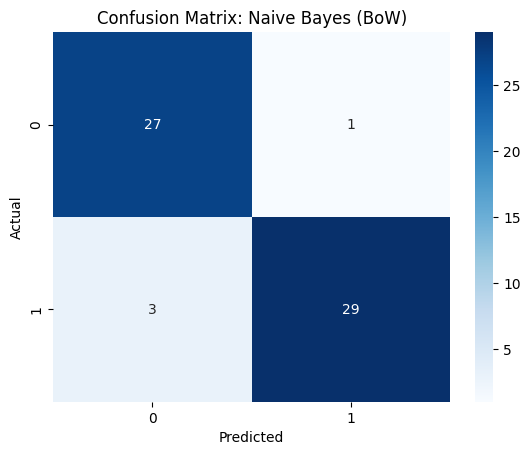


--- Naive Bayes (TF-IDF) ---
Accuracy : 0.95
Precision: 0.967741935483871
Recall   : 0.9375
F1-score : 0.9523809523809523


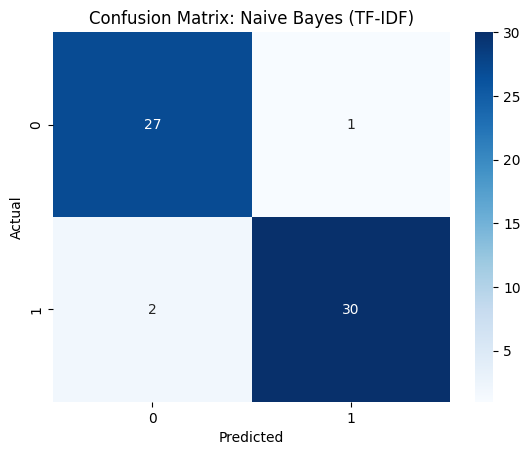


--- Logistic Regression (TF-IDF) ---
Accuracy : 0.95
Precision: 0.9142857142857143
Recall   : 1.0
F1-score : 0.9552238805970149


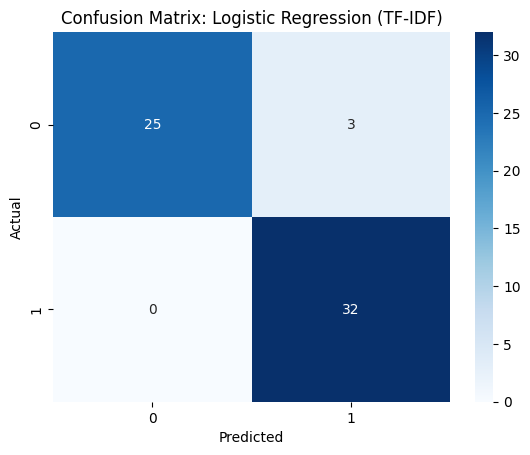


Comparison Table:
  Feature Method           Classifier  Accuracy  Precision   Recall        F1
0            BoW          Naive Bayes  0.933333   0.966667  0.90625  0.935484
1         TF-IDF          Naive Bayes  0.950000   0.967742  0.93750  0.952381
2         TF-IDF  Logistic Regression  0.950000   0.914286  1.00000  0.955224


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# Predictions
y_pred_nb_bow = nb_bow.predict(X_test_bow)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# Evaluate
evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (BoW)")
evaluate_model(y_test, y_pred_nb_tfidf, "Naive Bayes (TF-IDF)")
evaluate_model(y_test, y_pred_lr_tfidf, "Logistic Regression (TF-IDF)")

# Comparison Table
comparison = pd.DataFrame({
    "Feature Method": ["BoW", "TF-IDF", "TF-IDF"],
    "Classifier": ["Naive Bayes", "Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb_bow),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_lr_tfidf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nb_bow),
        precision_score(y_test, y_pred_nb_tfidf),
        precision_score(y_test, y_pred_lr_tfidf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb_bow),
        recall_score(y_test, y_pred_nb_tfidf),
        recall_score(y_test, y_pred_lr_tfidf)
    ],
    "F1": [
        f1_score(y_test, y_pred_nb_bow),
        f1_score(y_test, y_pred_nb_tfidf),
        f1_score(y_test, y_pred_lr_tfidf)
    ]
})

print("\nComparison Table:")
print(comparison)

**SAVE CLEAN DATASET**

In [ ]:
# Save cleaned dataset
df.to_csv("toxic_dataset_cleaned.csv", index=False)

**COMAPRISON TABLE**

| Feature Method | Classifier          | Accuracy | Precision | Recall | F1-score |
| -------------- | ------------------- | -------- | --------- | ------ | -------- |
| BoW            | Naive Bayes         | 0.93333    | 0.96667      | 0.90625   | 0.9354     |
| TF-IDF         | Naive Bayes         | 0.950000     | 0.967742      | 0.93570  | 0.9523     |
| TF-IDF         | Logistic Regression | 0.950000     | 1.000     | 1.000  | 0.955524    |


**CONCLUSIION**

After scraping 200 comments, we balanced the dataset with 100 abusive and 100 non-abusive comments. Preprocessing included lowercasing, punctuation removal, stopword removal, tokenization, and lemmatization. We extracted features using Bag of Words and TF-IDF. Three models were trained: Naive Bayes (BoW), Naive Bayes (TF-IDF), and Logistic Regression (TF-IDF). Logistic Regression with TF-IDF achieved the best performance (Accuracy=95%, F1-score=0.95). TF-IDF generally outperformed BoW, and the evaluation metrics suggest this pipeline is effective for toxic comment classification.